In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/player_clusters.csv")

cluster_summary = df.groupby("cluster")[[
    "matches_played",
    "total_minutes",
    "goals_per_90",
    "assists_per_90",
    "yellow_per_90",
    "red_per_90",
    "avg_market_value",
    "max_market_value",
    "height_in_cm",
    "age",
]].mean()

print(cluster_summary)

         matches_played  total_minutes  goals_per_90  assists_per_90  \
cluster                                                                
0             92.798417    5567.275110      0.223840        0.162392   
1             74.297473    5554.155604      0.042752        0.037592   
2            296.680265   21562.101433      0.174388        0.133215   

         yellow_per_90  red_per_90  avg_market_value  max_market_value  \
cluster                                                                  
0             0.181780    0.004008      2.071866e+06      5.070464e+06   
1             0.214966    0.006720      1.306917e+06      3.099080e+06   
2             0.180865    0.004203      1.415012e+07      3.257080e+07   

         height_in_cm        age  
cluster                           
0          179.097449  30.950923  
1          184.357240  32.744259  
2          182.455899  31.571665  


In [4]:
for c in sorted(df["cluster"].unique()):
    print("\n" + "="*40)
    print(f"CLUSTER {c}")

    display(
        df[df["cluster"] == c]
        .sort_values("avg_market_value", ascending=False)
        [["name", "position", "avg_market_value"]]
        .head(10)
    )


CLUSTER 0


,name,position,avg_market_value
15443,Oscar Bobb,Attack,2.333333e+07
16685,Vitor Roque,Attack,2.210833e+07
16212,Danilo,Midfield,2.092143e+07
14663,Thiago Almada,Attack,2.023529e+07
16597,Lewis Miley,Midfield,1.856250e+07
16721,Rodrigo Mora,Midfield,1.818333e+07
16257,Can Uzun,Midfield,1.755000e+07
16635,Pio Esposito,Attack,1.745000e+07
15323,Jhon Durán,Attack,1.705000e+07
16229,Eliesse Ben Seghir,Attack,1.703333e+07



CLUSTER 1


,name,position,avg_market_value
16811,Vitor Reis,Defender,2.280000e+07
76,Rio Ferdinand,Defender,1.892500e+07
450,Carles Puyol,Defender,1.873529e+07
1184,Nemanja Vidic‎,Defender,1.855714e+07
14540,James Trafford,Goalkeeper,1.677273e+07
13529,Max Aarons,Defender,1.492391e+07
16433,Lucas Beraldo,Defender,1.483333e+07
16159,André,Midfield,1.480312e+07
16564,Guillaume Restes,Goalkeeper,1.470000e+07
14643,Strahinja Pavlović,Defender,1.453571e+07



CLUSTER 2


,name,position,avg_market_value
11542,Kylian Mbappé,Attack,1.300600e+08
16672,Lamine Yamal,Attack,1.150000e+08
12851,Erling Haaland,Attack,1.027500e+08
14719,Jude Bellingham,Midfield,9.892857e+07
12129,Vinicius Junior,Attack,9.604167e+07
13049,Bukayo Saka,Attack,8.530435e+07
14700,Jamal Musiala,Midfield,8.516667e+07
14881,Florian Wirtz,Midfield,8.405882e+07
6747,Harry Kane,Attack,8.213333e+07
1694,Lionel Messi,Attack,7.996000e+07


In [5]:
display(
    df[df["cluster"] == c]
    .sort_values("goals_per_90", ascending=False)
    [["name", "position", "goals_per_90"]]
    .head(10)
)

,name,position,goals_per_90
12851,Erling Haaland,Attack,0.974145
496,Cristiano Ronaldo,Attack,0.944836
1694,Lionel Messi,Attack,0.909253
11542,Kylian Mbappé,Attack,0.905512
11162,Viktor Gyökeres,Attack,0.890832
2369,Robert Lewandowski,Attack,0.880429
1603,Sergio Agüero,Attack,0.862294
6747,Harry Kane,Attack,0.820918
104,Zlatan Ibrahimović,Attack,0.812342
3074,Edinson Cavani,Attack,0.746781


/tmp/ipykernel_121446/490086072.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


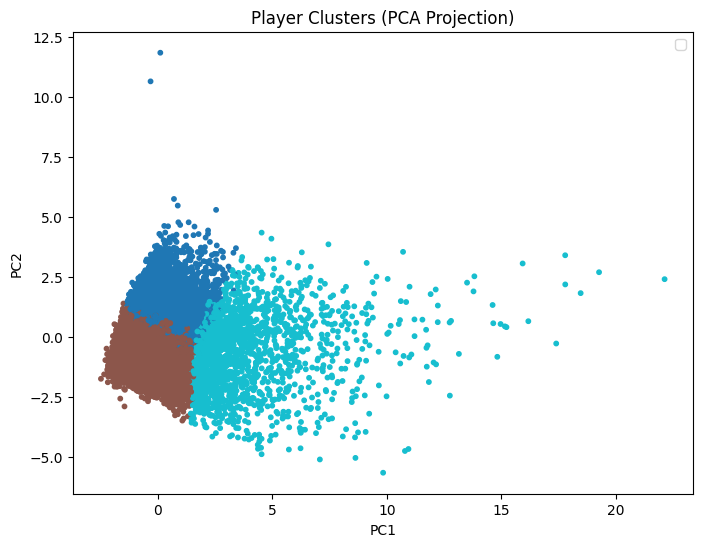

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

feature_columns = [
    "matches_played",
    "total_minutes",
    "goals_per_90",
    "assists_per_90",
    "yellow_per_90",
    "red_per_90",
    "avg_market_value",
    "max_market_value",
    "height_in_cm",
    "age",
]

X = df[feature_columns]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"], cmap="tab10", s=10)
plt.title("Player Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()